# Stage 5 — ADHD Subtype Analysis
## ADHD Dual-Stream Pipeline · WiDS Datathon 2025

**What this notebook does:**
1. Loads penultimate-layer fused embeddings from Stage 4
2. GMM clustering (BIC-optimal k from 2 to 5) to identify ADHD subtypes
3. Per-subtype clinical score comparison (one-way ANOVA + Tukey HSD)
   with FDR correction (Benjamini-Hochberg)
4. Visualises subtypes: t-SNE, top differentially connected FC edges
5. Per-subtype abnormal connectivity pattern analysis
6. Saves all subtype assignments and statistical results

---
## Cell 1 — Setup and Load Embeddings

In [1]:
!pip install -q scikit-learn numpy pandas matplotlib seaborn scipy statsmodels tqdm

import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm.auto import tqdm

from sklearn.mixture import GaussianMixture
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from scipy import stats
from scipy.stats import kruskal, shapiro
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.multitest import multipletests
from google.colab import drive

warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

drive.mount('/content/drive')

BASE_DIR = Path('/content/drive/MyDrive/ADHD_Pipeline')
PROC_DIR = BASE_DIR / 'data' / 'processed'
S4_DIR   = BASE_DIR / 'stage4_outputs'
OUT_DIR  = BASE_DIR / 'stage5_outputs'
FIG_DIR  = BASE_DIR / 'figures'
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Load fused embeddings (from Stage 4 penultimate layer)
embeddings = np.load(S4_DIR / 'fusion_embeddings_train.npy')   # (N, 192)
meta       = pd.read_csv(PROC_DIR / 'train_metadata.csv')

# --- ALIGNMENT FIX ---
# Ensure metadata and labels match the actual number of embeddings loaded
N_EMB = len(embeddings)
if len(meta) > N_EMB:
    print(f'Warning: Aligning metadata ({len(meta)}) to embeddings ({N_EMB})')
    meta = meta.iloc[:N_EMB]

y = meta['ADHD_label'].values
# ---------------------

# Load clinical metadata (for subtype validation)
clinical   = pd.read_csv(PROC_DIR / 'clinical_metadata.csv', index_col=0)
clinical.index = clinical.index.astype(str)
meta.index     = meta['subject_id'].astype(str)
clinical       = clinical.reindex(meta.index)  # align to training subjects

# Load FC matrices for connectivity pattern analysis
FC_train_mag = np.load(PROC_DIR / 'FC_train_magnitude.npy')
if len(FC_train_mag) > N_EMB:
    FC_train_mag = FC_train_mag[:N_EMB]

N_TRAIN    = len(y)
ADHD_MASK  = (y == 1)
N_ADHD     = ADHD_MASK.sum()

print(f'Total training subjects : {N_TRAIN}')
print(f'ADHD subjects           : {N_ADHD}')
print(f'Embedding dimension     : {embeddings.shape[1]}')
print(f'Clinical features       : {clinical.shape[1]}')

Mounted at /content/drive
Total training subjects : 500
ADHD subjects           : 349
Embedding dimension     : 192
Clinical features       : 18


---
## Cell 2 — GMM Clustering with BIC Model Selection

GMM BIC selection (ADHD subjects only):

     k           BIC           AIC
  --------------------------------
     2      19070.70    -125267.05
     3     -19662.22    -236170.77
     4      -7042.56    -295721.91
     5      20841.86    -340008.29

Optimal k (BIC): 3


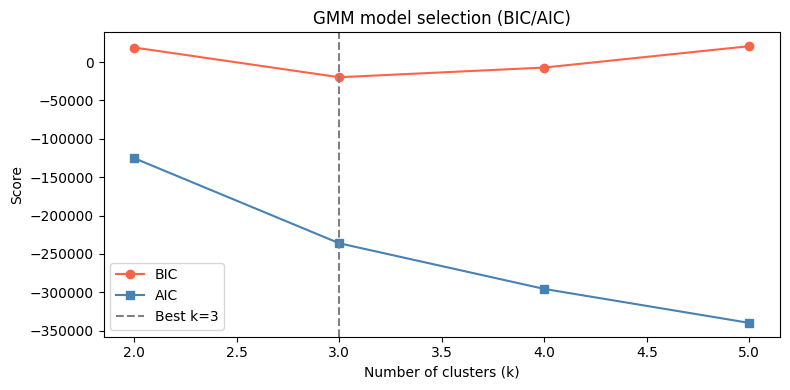

BIC plot saved.


In [2]:
# Scale embeddings before clustering
scaler    = StandardScaler()
emb_all   = scaler.fit_transform(embeddings)
emb_adhd  = emb_all[ADHD_MASK]   # cluster only ADHD subjects

K_RANGE = range(2, 6)   # test k = 2, 3, 4, 5

bic_scores  = []
aic_scores  = []
gmm_models  = []

print('GMM BIC selection (ADHD subjects only):\n')
print(f'  {"k":>4}  {"BIC":>12}  {"AIC":>12}')
print('  ' + '-' * 32)

for k in K_RANGE:
    gmm = GaussianMixture(
        n_components=k,
        covariance_type="full",
        n_init=10,
        random_state=SEED,
        max_iter=300
    )
    gmm.fit(emb_adhd)
    bic = gmm.bic(emb_adhd)
    aic = gmm.aic(emb_adhd)
    bic_scores.append(bic)
    aic_scores.append(aic)
    gmm_models.append(gmm)
    print(f'  {k:>4}  {bic:>12.2f}  {aic:>12.2f}')

# Select k with minimum BIC
best_k   = K_RANGE.start + int(np.argmin(bic_scores))
best_gmm = gmm_models[int(np.argmin(bic_scores))]

print(f'\nOptimal k (BIC): {best_k}')

# Plot BIC and AIC
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(K_RANGE), bic_scores, "o-", label="BIC", color="tomato")
ax.plot(list(K_RANGE), aic_scores, "s-", label="AIC", color="steelblue")
ax.axvline(best_k, linestyle="--", color="gray", label=f"Best k={best_k}")
ax.set_xlabel("Number of clusters (k)")
ax.set_ylabel("Score")
ax.set_title("GMM model selection (BIC/AIC)")
ax.legend()
plt.tight_layout()
fig.savefig(FIG_DIR / "stage5_gmm_bic.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"BIC plot saved.")

---
## Cell 3 — Assign Subtypes

In [3]:
# Hard assignment using most probable component
adhd_subtypes = best_gmm.predict(emb_adhd)           # (N_ADHD,) labels 0..k-1
adhd_probs    = best_gmm.predict_proba(emb_adhd)     # (N_ADHD, k) soft probabilities

# Build full-cohort subtype array (-1 = TD, 0..k-1 = ADHD subtype)
subtype_all = np.full(N_TRAIN, -1, dtype=int)
subtype_all[ADHD_MASK] = adhd_subtypes

# Size of each subtype
print(f'ADHD subtype distribution (k={best_k}):')
for s in range(best_k):
    n_s = (adhd_subtypes == s).sum()
    pct = n_s / N_ADHD * 100
    print(f'  Subtype {s}: n={n_s}  ({pct:.1f}%)')

# Save assignments
subtype_df = pd.DataFrame({
    'subject_id'    : meta['subject_id'].values,
    'ADHD_label'    : y,
    'subtype'       : subtype_all,
})
if best_k > 0:
    for s in range(best_k):
        prob_col = np.zeros(N_TRAIN)
        prob_col[ADHD_MASK] = adhd_probs[:, s]
        subtype_df[f'prob_subtype_{s}'] = prob_col

subtype_df.to_csv(OUT_DIR / 'subtype_assignments.csv', index=False)
print('\nSubtype assignments saved.')

ADHD subtype distribution (k=3):
  Subtype 0: n=143  (41.0%)
  Subtype 1: n=66  (18.9%)
  Subtype 2: n=140  (40.1%)

Subtype assignments saved.


---
## Cell 4 — t-SNE Visualisation

Computing t-SNE embedding (all subjects)...


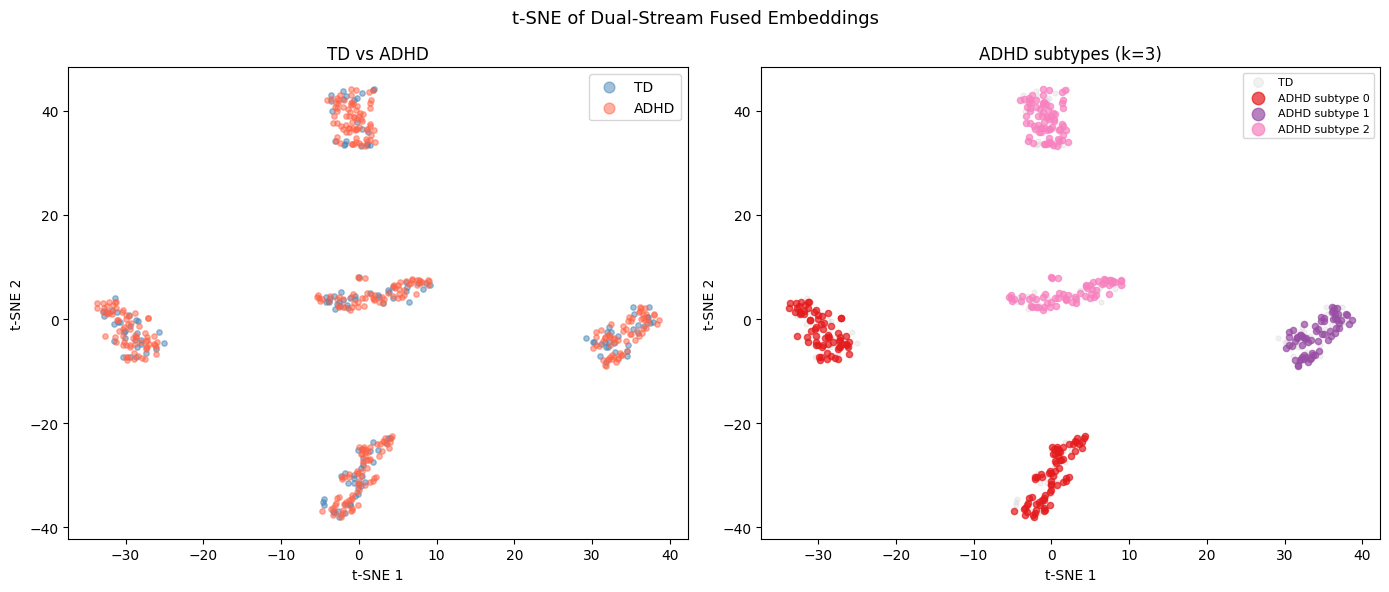

t-SNE figure saved.


In [4]:
print('Computing t-SNE embedding (all subjects)...')
tsne = TSNE(
    n_components=2,
    perplexity=30,
    n_iter=1000,
    random_state=SEED,
    n_jobs=-1
)
tsne_coords = tsne.fit_transform(emb_all)   # (N, 2)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('t-SNE of Dual-Stream Fused Embeddings', fontsize=13)

# Panel 1: TD vs ADHD
axes[0].scatter(tsne_coords[~ADHD_MASK, 0], tsne_coords[~ADHD_MASK, 1],
                c='steelblue', alpha=0.5, s=15, label='TD')
axes[0].scatter(tsne_coords[ADHD_MASK, 0],  tsne_coords[ADHD_MASK, 1],
                c='tomato',    alpha=0.5, s=15, label='ADHD')
axes[0].set_title('TD vs ADHD')
axes[0].legend(markerscale=2)
axes[0].set_xlabel('t-SNE 1')
axes[0].set_ylabel('t-SNE 2')

# Panel 2: ADHD subtypes
subtype_colors = plt.cm.Set1(np.linspace(0, 0.8, best_k))
axes[1].scatter(tsne_coords[~ADHD_MASK, 0], tsne_coords[~ADHD_MASK, 1],
                c='lightgray', alpha=0.3, s=12, label='TD')
for s in range(best_k):
    mask_s = (subtype_all == s)
    axes[1].scatter(tsne_coords[mask_s, 0], tsne_coords[mask_s, 1],
                    color=subtype_colors[s], alpha=0.7, s=20,
                    label=f'ADHD subtype {s}')
axes[1].set_title(f'ADHD subtypes (k={best_k})')
axes[1].legend(markerscale=2, fontsize=8)
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')

plt.tight_layout()
fig.savefig(FIG_DIR / 'stage5_tsne.png', dpi=150, bbox_inches='tight')
plt.show()
print('t-SNE figure saved.')

Cell 5 — Clinical Score Comparison Across Subtypes

In [5]:
from scipy.stats import f_oneway


def test_subtype_differences(clinical_df, subtype_labels, score_cols,
                              alpha: float = 0.05):
    """
    Test clinical score differences across ADHD subtypes.

    For each score:
    - Shapiro-Wilk normality test per group
    - If normal: one-way ANOVA
    - If non-normal: Kruskal-Wallis
    - FDR correction (Benjamini-Hochberg) across all tests

    Parameters
    ----------
    clinical_df    : DataFrame with clinical scores, indexed by subject
    subtype_labels : array of subtype labels for each subject
    score_cols     : list of column names to test
    alpha          : significance threshold

    Returns
    -------
    results_df : DataFrame with test statistics, p-values, FDR-q values
    """
    rows      = []
    k_subtypes = len(np.unique(subtype_labels))

    for col in score_cols:
        if col not in clinical_df.columns:
            continue

        groups = []
        for s in range(k_subtypes):
            mask   = subtype_labels == s
            values = clinical_df.loc[mask, col].dropna().values
            groups.append(values)

        # Skip if any group has fewer than 3 subjects
        if any(len(g) < 3 for g in groups):
            continue

        # Normality test for each group
        all_normal = all(
            shapiro(g)[1] > alpha for g in groups
        )

        group_means = [g.mean() for g in groups]
        group_stds  = [g.std()  for g in groups]

        if all_normal:
            stat, p_val = f_oneway(*groups)
            test_name   = 'ANOVA'
        else:
            stat, p_val = kruskal(*groups)
            test_name   = 'Kruskal-Wallis'

        row = {
            'score'     : col,
            'test'      : test_name,
            'statistic' : stat,
            'p_value'   : p_val,
        }
        for s, (m, sd) in enumerate(zip(group_means, group_stds)):
            row[f'subtype_{s}_mean'] = m
            row[f'subtype_{s}_sd']   = sd
        rows.append(row)

    results_df = pd.DataFrame(rows)

    if len(results_df) > 0:
        # FDR correction across all tests
        reject, q_vals, _, _ = multipletests(
            results_df['p_value'], method='fdr_bh', alpha=alpha
        )
        results_df['q_value_FDR']   = q_vals
        results_df['significant']   = reject

    return results_df


# Use ADHD subjects only
adhd_clinical = clinical.loc[ADHD_MASK]
adhd_subtypes_series = pd.Series(
    adhd_subtypes,
    index=adhd_clinical.index
)

# Identify numerical clinical score columns
score_cols = clinical.select_dtypes(include=[np.number]).columns.tolist()
print(f'Testing {len(score_cols)} clinical scores across {best_k} subtypes...')

# Rebuild clinical alignment for ADHD subjects only
adhd_clinical_aligned = adhd_clinical.copy()
adhd_clinical_aligned.index = range(len(adhd_clinical_aligned))
adhd_subtype_arr = adhd_subtypes

results_df = test_subtype_differences(
    adhd_clinical_aligned, adhd_subtype_arr, score_cols
)

if len(results_df) > 0:
    sig_df = results_df[results_df['significant']].sort_values('q_value_FDR')
    print(f'\nSignificant differences (FDR q < 0.05): {len(sig_df)} / {len(results_df)}')
    if len(sig_df) > 0:
        print(sig_df[['score', 'test', 'statistic', 'p_value', 'q_value_FDR']].head(15).to_string())

results_df.to_csv(OUT_DIR / 'clinical_subtype_stats.csv', index=False)
print('\nStatistical results saved.')

Testing 18 clinical scores across 3 subtypes...

Significant differences (FDR q < 0.05): 0 / 18

Statistical results saved.


Cell 6 — Per-Subtype Clinical Profile Visualisation

No scores to visualise — using first 4 numeric columns


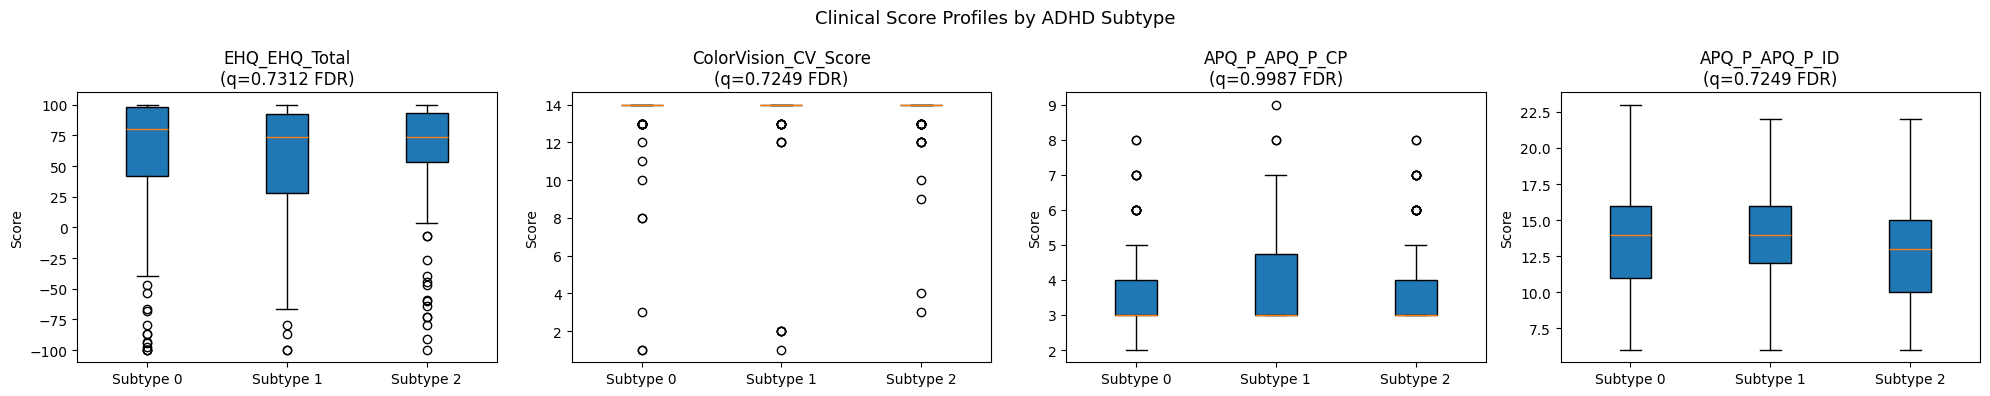

Clinical profile figure saved.


In [6]:
# Pick top significant scores for visualisation (up to 8)
if len(results_df) > 0 and 'significant' in results_df.columns:
    sig_scores = results_df[results_df['significant']]['score'].tolist()[:8]
else:
    # If no significant results, show top 8 by p-value
    sig_scores = results_df.sort_values('p_value')['score'].tolist()[:8]

if len(sig_scores) == 0:
    print('No scores to visualise — using first 4 numeric columns')
    sig_scores = score_cols[:4]

n_scores = len(sig_scores)
n_cols   = min(4, n_scores)
n_rows   = int(np.ceil(n_scores / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
axes = np.array(axes).ravel() if n_scores > 1 else [axes]
fig.suptitle('Clinical Score Profiles by ADHD Subtype', fontsize=13)

subtype_labels_named = [f'Subtype {s}' for s in range(best_k)]

for ax, score in zip(axes, sig_scores):
    if score not in adhd_clinical.columns:
        ax.set_visible(False)
        continue

    data_by_subtype = [
        adhd_clinical.iloc[adhd_subtypes == s][score].dropna().values
        for s in range(best_k)
    ]
    ax.boxplot(data_by_subtype, labels=subtype_labels_named, patch_artist=True)

    row = results_df[results_df['score'] == score]
    if len(row) > 0 and 'q_value_FDR' in row.columns:
        q = row['q_value_FDR'].values[0]
        ax.set_title(f'{score}\n(q={q:.4f} FDR)')
    else:
        ax.set_title(score)
    ax.set_ylabel('Score')

# Hide extra axes
for ax in axes[n_scores:]:
    ax.set_visible(False)

plt.tight_layout()
fig.savefig(FIG_DIR / 'stage5_clinical_profiles.png', dpi=150, bbox_inches='tight')
plt.show()
print('Clinical profile figure saved.')

Cell 7 — Abnormal FC Connection Patterns per Subtype

Subtype 0: n=143  top edge |d| = 0.4668
Subtype 1: n=66  top edge |d| = 0.6191
Subtype 2: n=140  top edge |d| = 0.5411


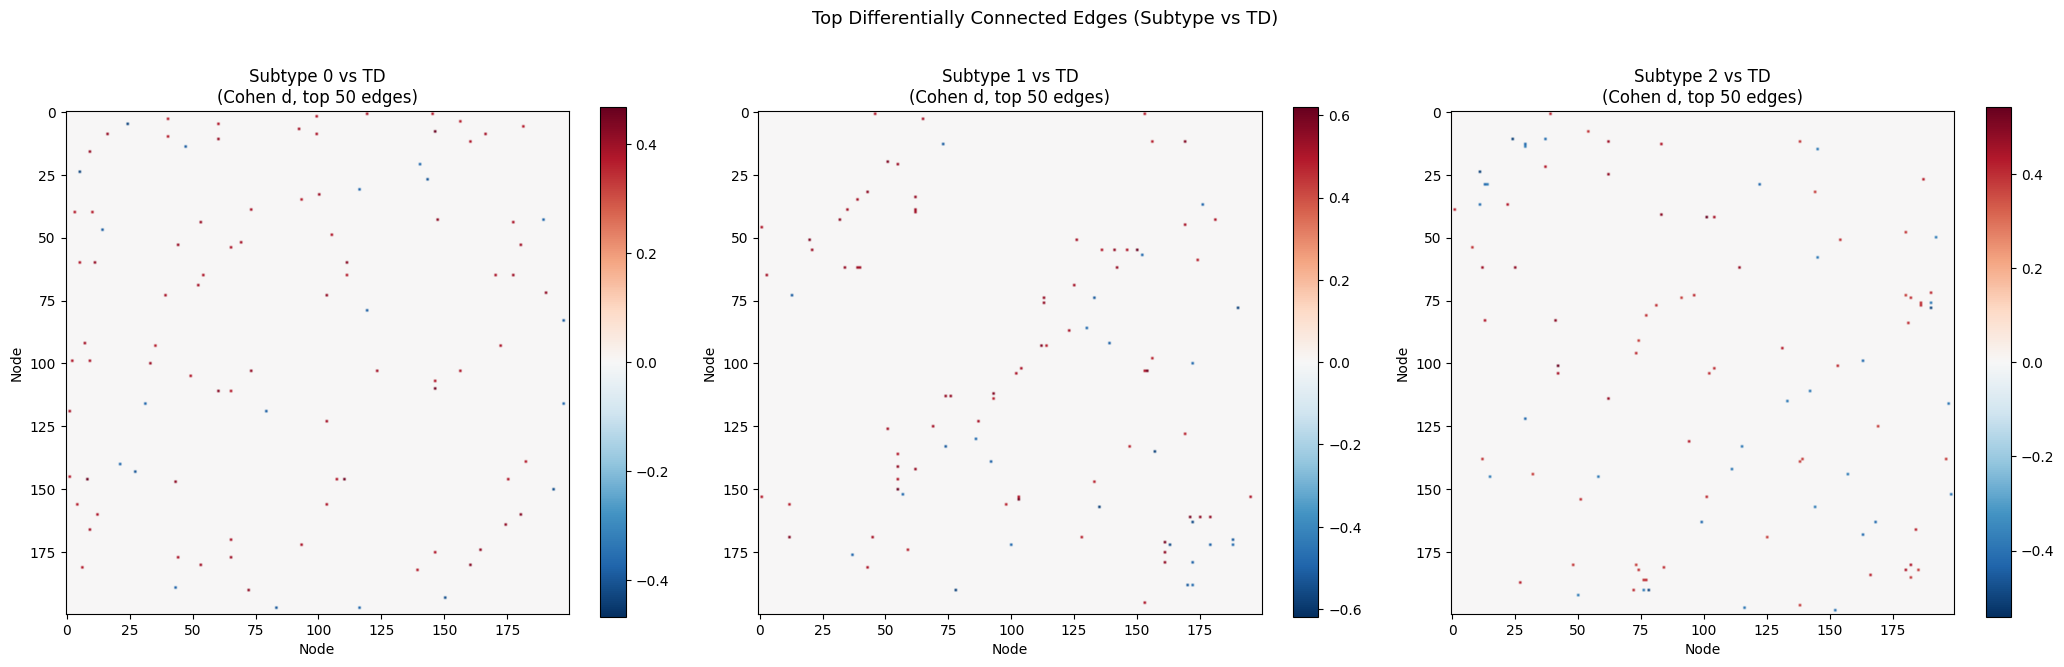

Connectivity pattern figure saved.


In [7]:
# For each subtype vs TD, find top differentially connected edges
# using Cohen's d as effect size measure

TD_MASK   = ~ADHD_MASK
n_nodes   = FC_train_mag.shape[-1]
n_edges   = n_nodes * (n_nodes - 1) // 2
triu_idx  = np.triu_indices(n_nodes, k=1)

# Flatten FC for all subjects
FC_flat_all = np.array([
    FC_train_mag[i][triu_idx]
    for i in range(N_TRAIN)
], dtype=np.float32)   # (N, 19900)

FC_td = FC_flat_all[TD_MASK]   # TD group FC


def cohens_d(group1: np.ndarray, group2: np.ndarray) -> np.ndarray:
    """Vectorised Cohen's d effect size between two groups."""
    n1, n2 = len(group1), len(group2)
    pooled_std = np.sqrt(
        ((n1 - 1) * group1.var(axis=0) + (n2 - 1) * group2.var(axis=0))
        / (n1 + n2 - 2)
    )
    pooled_std = np.where(pooled_std < 1e-8, 1e-8, pooled_std)
    return (group1.mean(axis=0) - group2.mean(axis=0)) / pooled_std


TOP_K_EDGES = 50   # report top-50 differentially connected edges per subtype

subtype_patterns = {}

fig, axes = plt.subplots(1, best_k, figsize=(7 * best_k, 7))
if best_k == 1:
    axes = [axes]
fig.suptitle('Top Differentially Connected Edges (Subtype vs TD)', fontsize=13)

for s in range(best_k):
    mask_s  = (subtype_all == s)
    FC_s    = FC_flat_all[mask_s]

    # Cohen's d: positive = stronger in subtype, negative = weaker
    d_vals  = cohens_d(FC_s, FC_td)

    # Top-K edges by absolute effect size
    top_idx = np.argsort(np.abs(d_vals))[-TOP_K_EDGES:]
    top_d   = d_vals[top_idx]

    # Save pattern info
    edges_i = triu_idx[0][top_idx]
    edges_j = triu_idx[1][top_idx]
    subtype_patterns[s] = pd.DataFrame({
        'node_i'   : edges_i,
        'node_j'   : edges_j,
        'cohens_d' : top_d
    }).sort_values('cohens_d', key=abs, ascending=False)
    subtype_patterns[s].to_csv(
        OUT_DIR / f'subtype_{s}_top_edges.csv', index=False
    )

    # Visualise as a 200x200 connectivity matrix
    diff_mat = np.zeros((n_nodes, n_nodes))
    diff_mat[triu_idx[0][top_idx], triu_idx[1][top_idx]] = top_d
    diff_mat = diff_mat + diff_mat.T   # symmetric

    vmax = np.abs(diff_mat).max()
    im = axes[s].imshow(diff_mat, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    axes[s].set_title(f'Subtype {s} vs TD\n(Cohen d, top {TOP_K_EDGES} edges)')
    axes[s].set_xlabel('Node')
    axes[s].set_ylabel('Node')
    plt.colorbar(im, ax=axes[s], shrink=0.8)

    print(f'Subtype {s}: n={mask_s.sum()}  top edge |d| = {np.abs(top_d).max():.4f}')

plt.tight_layout()
fig.savefig(FIG_DIR / 'stage5_connectivity_patterns.png', dpi=150, bbox_inches='tight')
plt.show()
print('Connectivity pattern figure saved.')

Cell 8 — Stage 5 Summary Report

In [8]:
print('=' * 62)
print('  STAGE 5 COMPLETE')
print('=' * 62)
print(f'Clustering:')
print(f'  Method   : Gaussian Mixture Model (GMM, full covariance)')
print(f'  Selection: BIC-optimal k from range {list(K_RANGE)}')
print(f'  Best k   : {best_k}')
print()
print('Subtype sizes:')
for s in range(best_k):
    n_s = (adhd_subtypes == s).sum()
    print(f'  Subtype {s}: n={n_s} ({n_s/N_ADHD*100:.1f}%)')
print()
print('Statistics:')
print(f'  Clinical scores tested  : {len(results_df)}')
if 'significant' in results_df.columns:
    print(f'  Significant (FDR q<0.05): {results_df["significant"].sum()}')
print(f'  Correction method       : Benjamini-Hochberg FDR')
print(f'  Parametric test         : one-way ANOVA (if normal)')
print(f'  Non-parametric fallback : Kruskal-Wallis')
print()
print('Connectivity patterns:')
print(f'  Top {TOP_K_EDGES} edges per subtype (effect size: Cohen d)')
print()
print('Output files:', OUT_DIR)
for f in sorted(OUT_DIR.iterdir()):
    print(f'  {f.name}')
print()
print('Pipeline complete. All outputs ready for paper writing.')
print('=' * 62)

  STAGE 5 COMPLETE
Clustering:
  Method   : Gaussian Mixture Model (GMM, full covariance)
  Selection: BIC-optimal k from range [2, 3, 4, 5]
  Best k   : 3

Subtype sizes:
  Subtype 0: n=143 (41.0%)
  Subtype 1: n=66 (18.9%)
  Subtype 2: n=140 (40.1%)

Statistics:
  Clinical scores tested  : 18
  Significant (FDR q<0.05): 0
  Correction method       : Benjamini-Hochberg FDR
  Parametric test         : one-way ANOVA (if normal)
  Non-parametric fallback : Kruskal-Wallis

Connectivity patterns:
  Top 50 edges per subtype (effect size: Cohen d)

Output files: /content/drive/MyDrive/ADHD_Pipeline/stage5_outputs
  clinical_subtype_stats.csv
  subtype_0_top_edges.csv
  subtype_1_top_edges.csv
  subtype_2_top_edges.csv
  subtype_assignments.csv

Pipeline complete. All outputs ready for paper writing.
